In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Bidirectional
)

In [ ]:
with open("//content/sikkim.txt", "r", encoding="utf-8") as file:

    text = file.read().lower()

In [ ]:
len(text)

10097

In [ ]:
VOCAB_SIZE = 1000
tokenizer = Tokenizer(num_words=VOCAB_SIZE)

tokenizer.fit_on_texts([text])

token_list = tokenizer.texts_to_sequences([text])[0]

In [ ]:
SEQUENCE_LENGTH = 5

input_sequences = []

for i in range(SEQUENCE_LENGTH, len(token_list)):

    seq = token_list[i-SEQUENCE_LENGTH:i+1]

    input_sequences.append(seq)

input_sequences = np.array(input_sequences)

In [ ]:
X = input_sequences[:, :-1]

y = input_sequences[:, -1]

#LSTM

In [ ]:
lstm_model = Sequential()

lstm_model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=32,
        input_length=SEQUENCE_LENGTH
    )
)

lstm_model.add(
    LSTM(32)
)

lstm_model.add(
    Dense(
        VOCAB_SIZE,
        activation='softmax'
    )
)

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_16 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_history = lstm_model.fit(
    X,
    y,
    epochs=50,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0682 - loss: 5.6000 - val_accuracy: 0.0730 - val_loss: 6.9591
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0682 - loss: 5.5912 - val_accuracy: 0.0730 - val_loss: 6.9692
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0682 - loss: 5.5836 - val_accuracy: 0.0730 - val_loss: 6.9966
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0682 - loss: 5.5761 - val_accuracy: 0.0730 - val_loss: 7.0246
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0682 - loss: 5.5686 - val_accuracy: 0.0730 - val_loss: 7.0514
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0682 - loss: 5.5620 - val_accuracy: 0.0730 - val_loss: 7.0773
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0682 - loss: 5.5552 - val_accuracy: 0.0730 - val_loss: 7.0992
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0682 - loss: 5.5489 - val_accuracy: 0.0730 - v

#BILSTM

In [ ]:
bilstm_model = Sequential()

bilstm_model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=32,
        input_length=SEQUENCE_LENGTH
    )
)

bilstm_model.add(
    Bidirectional(
        LSTM(32)
    )
)

bilstm_model.add(
    Dense(
        VOCAB_SIZE,
        activation='softmax'
    )
)

bilstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

bilstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_18 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
bilstm_history = bilstm_model.fit(
    X,
    y,
    epochs=50,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.0341 - loss: 6.9052 - val_accuracy: 0.0657 - val_loss: 6.9017
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0836 - loss: 6.8914 - val_accuracy: 0.0803 - val_loss: 6.8931
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0812 - loss: 6.8685 - val_accuracy: 0.0730 - val_loss: 6.8737
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0706 - loss: 6.8122 - val_accuracy: 0.0730 - val_loss: 6.8245
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0682 - loss: 6.6475 - val_accuracy: 0.0730 - val_loss: 6.6965
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0682 - loss: 6.2416 - val_accuracy: 0.0730 - val_loss: 6.5653
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0682 - loss: 5.8794 - val_accuracy: 0.0730 - val_loss: 6.7561
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0682 - loss: 5.8124 - val_accuracy: 0.0730 - v

TO generate next few words creating a def function

In [ ]:
def predict_next_words(model, tokenizer, text, sequence_length, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([text])[0]

        token_list = token_list[-sequence_length:]

        token_list = pad_sequences(
            [token_list],
            maxlen=sequence_length,
            padding='pre'
        )

        predictions = model.predict(token_list, verbose=0)[0]

        predicted_index = np.random.choice(
            len(predictions),
            p=predictions
        )

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted_index:

                output_word = word
                break

        text += " " + output_word

    return text

In [ ]:
print(
    predict_next_words(
        lstm_model,
        tokenizer,
        "traditionaly",
        SEQUENCE_LENGTH
    )
)

traditionaly expansion  sheep future serves understanding numerous and for and


In [ ]:
print(
    predict_next_words(
        bilstm_model,
        tokenizer,
        "traditionaly",
        SEQUENCE_LENGTH
    )
)

traditionaly and site economy practices infrastructure and lepcha are blue the


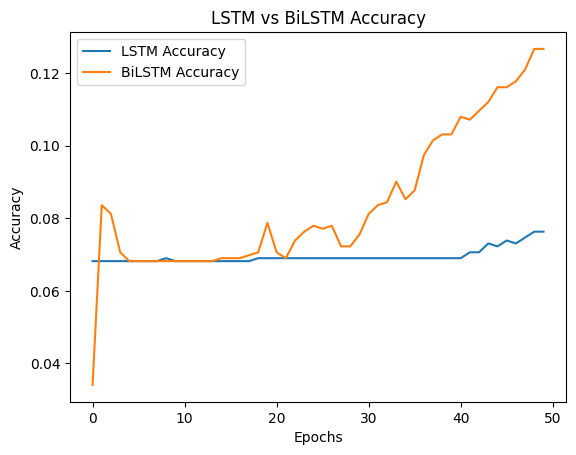

In [ ]:
plt.plot(
    lstm_history.history['accuracy'],
    label='LSTM Accuracy'
)

plt.plot(
    bilstm_history.history['accuracy'],
    label='BiLSTM Accuracy'
)

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.title("LSTM vs BiLSTM Accuracy")

plt.show()

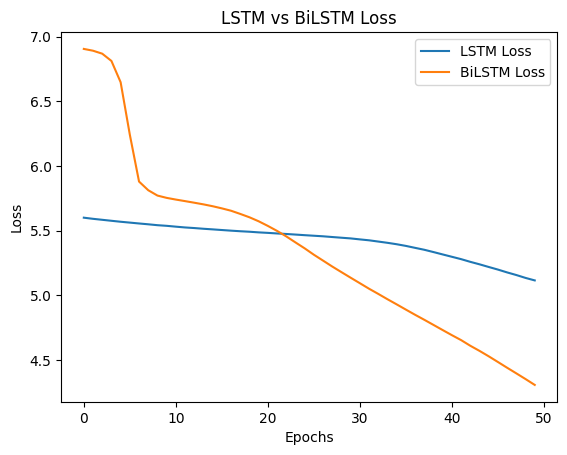

In [ ]:
plt.plot(
    lstm_history.history['loss'],
    label='LSTM Loss'
)

plt.plot(
    bilstm_history.history['loss'],
    label='BiLSTM Loss'
)

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.title("LSTM vs BiLSTM Loss")

plt.show()